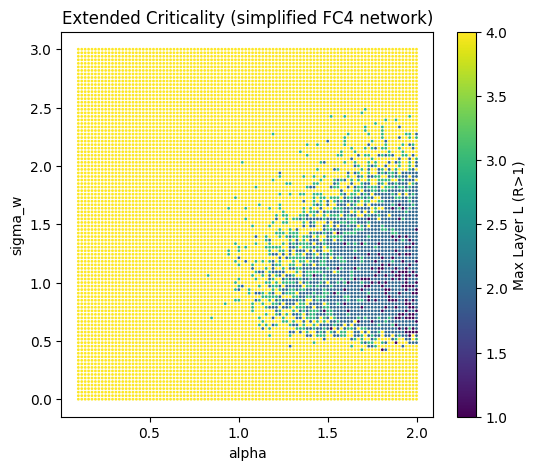

In [1]:
import numpy as np
from scipy.stats import levy_stable
import matplotlib.pyplot as plt

# ----------------
# Netzwerkparameter
# ----------------
N_in = 100      # Input dimension
N_hidden = 100    # Hidden layer dimension
L = 8          # Number of layers

# Heavy-tailed / Gaussian parameter
alpha = 1.5      # Levy alpha < 2 for heavy-tailed, alpha=2 for Gaussian
sigma_w = 1.2    # Weight gain

# Funktion zur Initialisierung
def init_weights(N_in, N_out, alpha, sigma_w):
    if alpha == 2.0:
        # Gaussian
        return sigma_w * np.random.randn(N_out, N_in) / np.sqrt(N_in)
    else:
        # Levy-stable
        return levy_stable.rvs(alpha, 0, size=(N_out, N_in)) * (sigma_w * (0.5/N_in)**(1./alpha))


def forward_jacobian(x, Ws):
    """x: input vector, Ws: list of weight matrices"""
    hs = [x]
    Js = []
    for W in Ws:
        h = np.tanh(W @ hs[-1])
        D = np.diag(1 - h**2)   # tanh derivative
        Js.append(W @ D)
        hs.append(h)
    return hs, Js

def jacobian_average(J, f=np.log):
    eigvals = np.linalg.eigvals(J)
    return np.mean(f(np.abs(eigvals) + 1e-12))  # avoid log(0)


alphas = np.linspace(0.1, 2.0, 100)       # small example
sigmas = np.linspace(0, 3.0, 100)
L_layers = 4

# Reference: ordered transition = simple Gaussian edge-of-chaos
ref_alpha = 2.0
ref_sigma = 1.0

x, y, Lmax_map = [], [], []

for alpha_val in alphas:
    for sigma_val in sigmas:
        # Init weights for L layers
        Ws = [init_weights(N_hidden, N_hidden, alpha_val, sigma_val) for _ in range(L_layers)]
        x0 = np.random.randn(N_hidden)
        
        # Forward + Jacobians
        hs, Js = forward_jacobian(x0, Ws)
        
        # Compute ratio R(L) per layer
        R_L = []
        # Reference Jacobian
        Ws_ref = [init_weights(N_hidden, N_hidden, ref_alpha, ref_sigma) for _ in range(L_layers)]
        _, Js_ref = forward_jacobian(x0, Ws_ref)
        J_ref_avg = jacobian_average(Js_ref[0], f=np.log)
        
        for J in Js:
            R = jacobian_average(J, f=np.log) / J_ref_avg
            R_L.append(R)
        
        # Find max L where R > 1
        Lmax = next((i+1 for i, R in enumerate(R_L) if R < 1), L_layers)
        x.append(alpha_val)
        y.append(sigma_val)
        Lmax_map.append(Lmax)


plt.figure(figsize=(6,5))
plt.scatter(x, y, c=Lmax_map, s=1, cmap='viridis')
plt.colorbar(label='Max Layer L (R>1)')
plt.xlabel('alpha')
plt.ylabel('sigma_w')
plt.title('Extended Criticality (simplified FC4 network)')
plt.show()

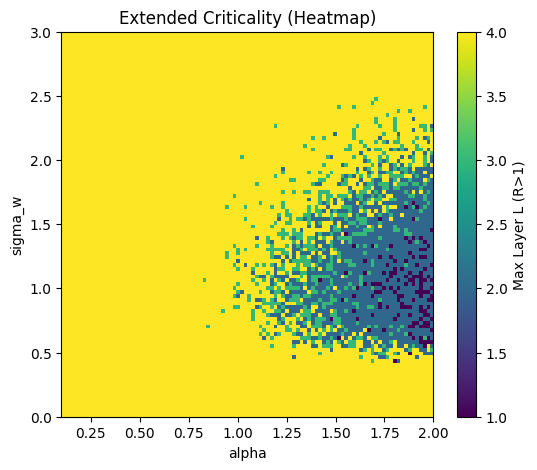

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Angenommen, x, y, Lmax_map sind deine bisherigen Arrays

# 1. Gitter erstellen
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
X_grid, Y_grid = np.meshgrid(xi, yi)

# 2. Interpolieren auf das Gitter
Z_grid = griddata((x, y), Lmax_map, (X_grid, Y_grid), method='nearest')  # nearest für diskrete Werte

# 3. Heatmap plotten
plt.figure(figsize=(6,5))
plt.imshow(Z_grid, origin='lower', extent=[min(x), max(x), min(y), max(y)],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Max Layer L (R>1)')
plt.xlabel('alpha')
plt.ylabel('sigma_w')
plt.title('Extended Criticality (Heatmap)')
plt.show()
